# Tratando os dados de internações

Este notebook consolida as **internações por doenças respiratórias** (SUS) no **município do Rio de Janeiro** e prepara a **série diária de internações** para modelagem.
O foco é: leitura dos dados brutos anuais, filtros clínicos e geográficos coerentes com exposição ambiental e uma **análise exploratória inicial**.

> **Escopo**: 2012–2025, diagnósticos respiratórios (CID-10 selecionados), residentes da cidade do Rio e permanência hospitalar > 0.

## Objetivos desta etapa
1. **Carregar** todos os parquet anuais (2012–2025) diretamente do GitHub (*raw*).
2. **Padronizar** campos-chave (datas, CID-10) e **filtrar** registros de interesse.
3. **Construir** a série **diária** de internações (`data_dia` × `internacoes`).

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import linregress
import re

In [26]:
teste = pd.read_parquet(r"C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\RawData\DataSus\teste\dados_filtrados_2008.parquet")

teste.to_csv(r"C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\RawData\DataSus\teste\dados_filtrados_2008.csv", index=False)

teste2 = pd.read_parquet(r"C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\RawData\DataSus\teste\dados_filtrados_2018.parquet")

teste2.to_csv(r"C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\RawData\DataSus\teste\dados_filtrados_2018.csv", index=False)

In [2]:
INTERNACOES_ANOS_INTERESSE = range(2008, 2019)

ANOS_ESTABELECIMENTOS = range(2012, 2019)

URL_ESTABELECIMENTOS = (
    "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/"
    "refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/cnes/"
    "estabelecimento_saude_rj_{ano}.parquet"
)

URL_INTERNACOES = ("https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_{ano}.parquet")

#### Funções auxiliares

In [3]:
def limpar_documento(value, tamanho=None):
    """Remove tudo que não for dígito e, se solicitado, preenche à esquerda com zeros."""
    if pd.isna(value):
        return pd.NA

    if isinstance(value, float) and value.is_integer():
        value = int(value)

    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]

    digits = re.sub(r"\D", "", text)

    if not digits:
        return pd.NA

    if tamanho is not None:
        if len(digits) > tamanho:
            return pd.NA
        digits = digits.zfill(tamanho)

    return digits


def limpar_cep(value):
    """Padroniza o CEP em 8 dígitos. Retorna NA se o valor for inválido."""
    return limpar_documento(value, tamanho=8)


def limpar_cnpj(value):
    """Padroniza CNPJ/CPF_CNPJ em 14 dígitos."""
    return limpar_documento(value, tamanho=14)

## Carregamento dos dados

### Dados dos estabelecimentos de saúde (CNES)

In [4]:
df_estabelecimentos = pd.DataFrame()

for ano in ANOS_ESTABELECIMENTOS:
    url = URL_ESTABELECIMENTOS.format(ano=ano)
    df_ano = pd.read_parquet(url)
    df_ano["ANO_REF"] = ano
    df_estabelecimentos = pd.concat([df_estabelecimentos, df_ano], ignore_index=True)

print("Dimensão consolidada de estabelecimentos:", df_estabelecimentos.shape)
display(df_estabelecimentos.head())

Dimensão consolidada de estabelecimentos: (686201, 6)


,CNES,CODUFMUN,COD_CEP,CPF_CNPJ,COD_IR,ANO_REF
0,2288354,330455,20745150,00000000000000,10,2012
1,2280221,330455,22241010,42144253000189,,2012
2,2295857,330170,25030120,00000000000000,10,2012
3,2277271,330455,20941160,29468055000102,,2012
4,2271257,330455,21032000,28000107000744,,2012


### Dados das internações (SIH)

In [5]:
anos = range(2008, 2026)

dfs = []
for ano in anos:
    url = URL_INTERNACOES.format(ano=ano)
    print(f"Lendo: {url}")
    df = pd.read_parquet(url)
    dfs.append(df)

df_sus = pd.concat(dfs, ignore_index=True)

Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_2008.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_2009.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_2010.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_2011.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_2012.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/teste/dados_filtrados_2013.parquet
Lendo: https://raw.githubuserconte

## Inspeção inicial

Visão geral de dimensões, tipos, amostra e dados ausentes. A coluna de data principal
virá de `DT_INTER` (quando numérica tipo `YYYYMMDD`) ou de `data_formatada` (se já estiver disponível).

In [6]:
print("Dimensões:", df_sus.shape)

print("\nTipos:")
print(df_sus.dtypes)

print("\nAmostra:")
display(df_sus.head(5))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_sus.isna().sum().sort_values(ascending=False)
na_perc   = (df_sus.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (834309, 16)

Tipos:
CGC_HOSP          string
MUNIC_RES         string
NASC              string
SEXO               Int64
DT_INTER          string
DT_SAIDA          string
DIAG_PRINC        string
DIAG_SECUN        string
IDADE             string
COD_IDADE         string
RACA_COR          string
ETNIA             string
DIAS_PERM         string
MORTE             string
CID_MORTE         string
data_formatada       str
dtype: object

Amostra:


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
0,29063294000182,330030,20070917,1,20080101,20080106,J219,,3,3,01,,5,0,,2008-01-01
1,32491672000133,330630,19470628,1,20080101,20080103,J158,,60,4,01,,2,1,R092,2008-01-01
2,31935349000149,330510,19681229,1,20080101,20080131,J449,,39,4,04,,30,0,,2008-01-01
3,31935349000149,330350,19720214,1,20080101,20080131,J448,,35,4,01,,30,0,,2008-01-01
4,32491672000133,330630,19510710,1,20080101,20080110,J81,,56,4,01,,9,0,,2008-01-01



Valores ausentes por coluna (top 20):


,NA_count,NA_%
CGC_HOSP,0,0.0
MUNIC_RES,0,0.0
NASC,0,0.0
SEXO,0,0.0
DT_INTER,0,0.0
DT_SAIDA,0,0.0
DIAG_PRINC,0,0.0
DIAG_SECUN,0,0.0
IDADE,0,0.0
COD_IDADE,0,0.0


## Filtrando dados de saúde

### Filtrando por anos de interesse

Nesta etapa, vamos manter apenas os registros de internação com data entre **2008 e 2018** (inclusive).

Você pode perguntar:  
> “Por que carregar dados de anos posteriores a 2018, se o período de interesse é 2012–2018?”

A resposta é:
- Os dados de internação podem ser inseridos retrospectivamente (registro post-mortem).
- Por isso, eventos de anos anteriores podem aparecer em cargas feitas após 2018.
- Carregar os arquivos até 2025 garante captura completa dos registros de 2012–2018.

A outras pergunta que você deve estar fazendo é:  
> “Por que carregar dados de anos anteriores a 2012, se o período de interesse é 2012–2018?”

A resposta é:
- Durante a etapa de engenharia de features, são criadas variáveis que dependem de informações passadas, como:

    - Lags (ex: valor em ( t-1 ), ( t-7 ), ( t-14 ))
    - Médias móveis (ex: média dos últimos 7, 30 dias)
    - Estatísticas rolling (desvio padrão, máximos, mínimos)
    - Features baseadas em decomposição STL

- Essas transformações exigem um histórico mínimo de dados anteriores para serem calculadas corretamente.

⚠️ O problema de não usar histórico

- Se utilizarmos apenas dados a partir de 2012:

    - As primeiras observações não terão histórico suficiente
    - Muitas features resultarão em valores NaN
    - Seria necessário remover essas linhas

👉 Isso levaria à perda de dados logo no início do período de interesse, o que é indesejável.

🔥 Solução: Burn-in period (ou Buffer histórico)

- Para resolver esse problema, utilizamos um conceito chamado: **Burn-in period (ou buffer histórico)** que consiste em incluir um período anterior ao intervalo de interesse apenas para:
    - “alimentar” o cálculo das features
    - estabilizar transformações como STL
    - garantir que todas as variáveis estejam completas no início da análise

In [7]:
df_sus['data_formatada'] = pd.to_datetime(df_sus['data_formatada'], errors='coerce')

df_sus = df_sus[df_sus['data_formatada'].dt.year.isin(INTERNACOES_ANOS_INTERESSE)].copy()
df_sus.sort_values('data_formatada', inplace=True)

print(df_sus.shape)
display(df_sus.head())
display(df_sus.tail())

(559615, 16)


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
0,29063294000182,330030,20070917,1,20080101,20080106,J219,,3,3,01,,5,0,,2008-01-01
122,31684384000132,330330,19500615,3,20080101,20080104,J449,,57,4,01,,3,0,,2008-01-01
123,00394544020372,330455,19290302,3,20080101,20080102,J960,,78,4,99,,1,1,R688,2008-01-01
124,29205994000164,330190,19420311,3,20080101,20080107,J449,,65,4,03,,6,0,,2008-01-01
125,00830507000172,330350,20051201,3,20080101,20080104,J158,,2,4,03,,3,0,,2008-01-01


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
559585,29468055000374,330170,19210304,3,20181231,20190109,J189,0000,97,4,01,0000,9,0,0000,2018-12-31
559586,32354011001219,330610,19330212,3,20181231,20190109,J189,0000,85,4,01,0000,9,0,0000,2018-12-31
559587,29138351001206,330170,20100612,3,20181231,20190109,J129,0000,8,4,99,0000,9,0,0000,2018-12-31
559589,29063294000182,330630,19550522,1,20181231,20190106,J189,0000,63,4,04,0000,6,1,0000,2018-12-31
559614,00830507000172,330414,20181031,3,20181231,20190103,J158,0000,2,3,99,0000,3,0,0000,2018-12-31


### Filtrando por CID-10 de Interesse

Nesta etapa, serão filtrados os códigos CID-10 relevantes para nossa análise:

**Códigos selecionados:**
- **Pneumonia:** J18, J15
- **Insuficiência Respiratória:** J21, J96  
- **Bronquites:** J40, J41, J42
- **Enfisema/DPOC:** J43, J44
- **Asma:** J45, J46

In [8]:
cids_associados_a_poluicao = {"J15","J18","J21","J96","J40","J41","J42","J43","J44","J45","J46"}

# Limpando a coluna DIAG_PRINC: convertendo para string, maiúsculas, removendo espaços e caracteres não alfanuméricos
df_sus["DIAG_PRINC"] = (df_sus["DIAG_PRINC"].astype(str).str.upper().str.strip().str.replace(r"[^A-Z0-9]", "",regex=True))

# Extraindo os primeiros 3 caracteres como prefixo CID
df_sus["CID_PREFIXO"] = df_sus["DIAG_PRINC"].str[:3]

# Filtrando o dataframe para incluir apenas linhas com prefixos CID relevantes
sus_filtrado = df_sus[df_sus["CID_PREFIXO"].isin(cids_associados_a_poluicao)].copy()

print(f"Filtered data shape: {sus_filtrado.shape}")
print("\nCID prefix counts:")
print(sus_filtrado["CID_PREFIXO"].value_counts())
print("\nFirst 5 rows of filtered data:")
display(sus_filtrado.head())

Filtered data shape: (421319, 17)

CID prefix counts:
CID_PREFIXO
J18    145943
J15    113370
J45     49169
J44     31548
J21     26394
J96     22305
J40     13504
J46      7479
J43      6451
J41      4257
J42       899
Name: count, dtype: int64

First 5 rows of filtered data:


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,CID_PREFIXO
0,29063294000182,330030,20070917,1,20080101,20080106,J219,,3,3,01,,5,0,,2008-01-01,J21
122,31684384000132,330330,19500615,3,20080101,20080104,J449,,57,4,01,,3,0,,2008-01-01,J44
123,00394544020372,330455,19290302,3,20080101,20080102,J960,,78,4,99,,1,1,R688,2008-01-01,J96
124,29205994000164,330190,19420311,3,20080101,20080107,J449,,65,4,03,,6,0,,2008-01-01,J44
125,00830507000172,330350,20051201,3,20080101,20080104,J158,,2,4,03,,3,0,,2008-01-01,J15


### Filtrando por Estabelecimentos de Sáude que fiquem nos municípios de interesse
- A filtragem dos municípios fica no código responsável por baixar os dados do CNES

#### Municípios Selecionados

- **330455** - Rio de Janeiro
- **330510** - São João de Meriti
- **330320** - Nilópolis
- **330285** - Mesquita
- **330045** - Belford Roxo
- **330350** - Nova Iguaçu
- **330170** - Duque de Caxias

In [9]:
sus_filtrado["CGC_HOSP"] = sus_filtrado["CGC_HOSP"].apply(limpar_cnpj)
df_estabelecimentos["CPF_CNPJ"] = df_estabelecimentos["CPF_CNPJ"].apply(limpar_cnpj)

estabelecimentos_saude_unicos = df_estabelecimentos['CPF_CNPJ'].unique()
print(f"Quantidade de estabelecimentos de saúde únicos no DataFrame: {len(sus_filtrado['CGC_HOSP'].unique())}")

sus_filtrado = sus_filtrado[sus_filtrado['CGC_HOSP'].isin(estabelecimentos_saude_unicos)]

print(f"Quantidade de estabelecimentos de saúde únicos no DataFrame após filtrar por estabelecimentos de saúde do Rio de Janeiro: {len(sus_filtrado['CGC_HOSP'].unique())}")

print("Dimensões após filtro por estabelecimentos de saúde do Rio de Janeiro:", sus_filtrado.shape)
display(sus_filtrado.head())

Quantidade de estabelecimentos de saúde únicos no DataFrame: 225
Quantidade de estabelecimentos de saúde únicos no DataFrame após filtrar por estabelecimentos de saúde do Rio de Janeiro: 79
Dimensões após filtro por estabelecimentos de saúde do Rio de Janeiro: (168908, 17)


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,CID_PREFIXO
123,00394544020372,330455,19290302,3,20080101,20080102,J960,,78,4,99,,1,1,R688,2008-01-01,J96
126,29138278003208,330350,20061209,3,20080101,20080109,J188,,1,4,99,,8,0,,2008-01-01,J18
121,29138286000158,330350,19411123,1,20080101,20080118,J152,,66,4,99,,17,0,,2008-01-01,J15
142,34293662000119,330455,19331202,1,20080101,20080323,J188,,74,4,01,,82,0,,2008-01-01,J18
120,00254512000184,330350,20050815,3,20080101,20080104,J158,,2,4,03,,3,0,,2008-01-01,J15



## Série diária de internações Rio de Janeiro


### Corrigindo data

In [10]:
sus_filtrado["data_dia"] = pd.to_datetime(sus_filtrado["data_formatada"], errors="coerce").dt.normalize()

sus_filtrado = sus_filtrado.dropna(subset=["data_dia"])

### Gerando quantidade de internações por dia

In [11]:
internacoes_diario = (
    sus_filtrado.groupby("data_dia")
    .size()
    .rename("num_internacoes")
    .astype("int64")
    .reset_index()
    .sort_values("data_dia")
)

### Preenchendo calendário
Preencher calendário (datas faltantes -> 0 internações)

In [12]:
idx_full = pd.date_range(internacoes_diario["data_dia"].min(),
                        internacoes_diario["data_dia"].max(),
                        freq="D")

internacoes_rj = (
    internacoes_diario.set_index("data_dia")
    .reindex(idx_full, fill_value=0)
    .rename_axis("data_dia")
    .reset_index()
)

### Gerando CSV de saída

In [13]:
project_root = Path().resolve().parents[2]
output_dir = project_root / "Data" / "IntermediaryData" / "DataSus"
output_dir.mkdir(parents=True, exist_ok=True)

output_parquet_path = output_dir / "respiratory_hospitalization_time_series.parquet"
internacoes_rj.to_parquet(output_parquet_path, index=False)

print(f"Arquivo salvo em: {output_parquet_path}")

Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\DataSus\respiratory_hospitalization_time_series.parquet


### Série temporal de internações

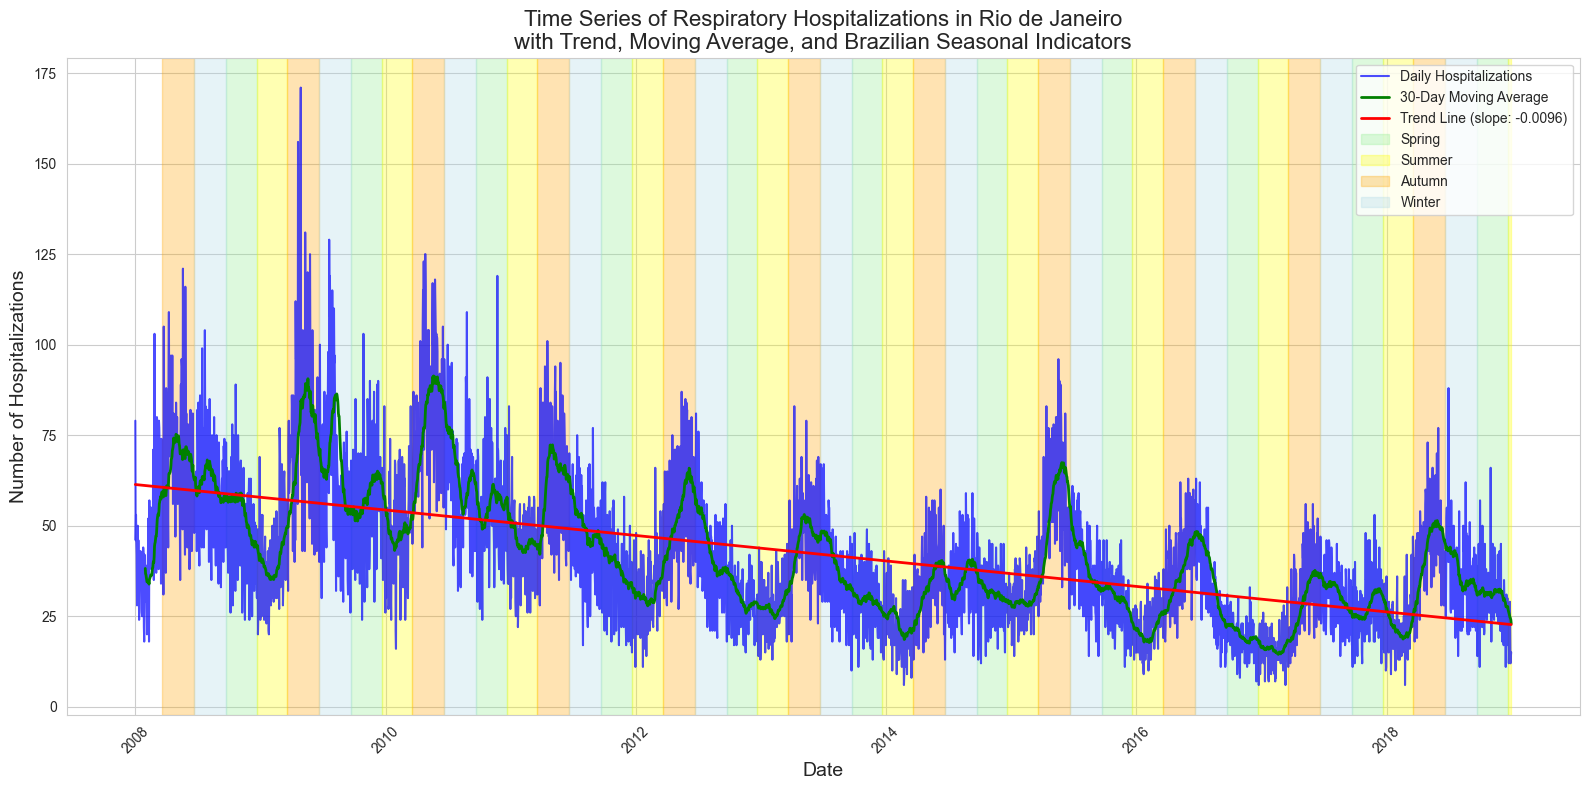

In [14]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Série temporal de hospitalizações diárias
plt.plot(internacoes_rj['data_dia'], internacoes_rj['num_internacoes'], linewidth=1.5, color='blue', alpha=0.7, label='Daily Hospitalizations')

# Média móvel de 30 dias
internacoes_rj['moving_avg_30'] = internacoes_rj['num_internacoes'].rolling(window=30).mean()
plt.plot(internacoes_rj['data_dia'], internacoes_rj['moving_avg_30'], linewidth=2, color='green', label='30-Day Moving Average')

# Calcula a tendência linear (slope) e plota a linha de tendência
x_numeric = (internacoes_rj['data_dia'] - internacoes_rj['data_dia'].min()).dt.days
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, internacoes_rj['num_internacoes'])
trend_line = slope * x_numeric + intercept
plt.plot(internacoes_rj['data_dia'], trend_line, color='red', linewidth=2, label=f'Trend Line (slope: {slope:.4f})')

# Adicionar indicadores sazonais brasileiros (estações do ano)
start_date = internacoes_rj['data_dia'].min()
end_date = internacoes_rj['data_dia'].max()

# Datas das estações do ano
def get_season_periods(year):
    return [
        ('Spring', pd.Timestamp(year=year, month=9, day=22), pd.Timestamp(year=year, month=12, day=21)),
        ('Summer', pd.Timestamp(year=year, month=12, day=21), pd.Timestamp(year=year+1, month=3, day=20)),
        ('Autumn', pd.Timestamp(year=year, month=3, day=20), pd.Timestamp(year=year, month=6, day=21)),
        ('Winter', pd.Timestamp(year=year, month=6, day=21), pd.Timestamp(year=year, month=9, day=22))
    ]

season_colors = {
    'Spring': ('lightgreen', 0.3),
    'Summer': ('yellow', 0.3),
    'Autumn': ('orange', 0.3),
    'Winter': ('lightblue', 0.3)
}

for year in range(start_date.year, end_date.year + 1):
    season_periods = get_season_periods(year)
    for season_name, season_start, season_end in season_periods:
        # Adjust for data range
        actual_start = max(season_start, start_date)
        actual_end = min(season_end, end_date)
        if actual_start < actual_end:
            color, alpha = season_colors[season_name]
            plt.axvspan(actual_start, actual_end, color=color, alpha=alpha, label=season_name if year == start_date.year else "")

plt.title('Time Series of Respiratory Hospitalizations in Rio de Janeiro\nwith Trend, Moving Average, and Brazilian Seasonal Indicators', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Hospitalizations', fontsize=14)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Serie diaria de internacoes por Unidade Hospitalar

Nesta secao, geramos a serie diaria por unidade hospitalar, agrupando por `data_dia` e `CGC_HOSP`.

### Agrupando por Unidade Hospitalar e data

In [15]:
internacoes_diario_hospital = (
    sus_filtrado
    .groupby(['CGC_HOSP', 'data_dia'])
    .size()
    .rename('num_internacoes')
    .astype('int64')
    .reset_index()
    .sort_values(['CGC_HOSP', 'data_dia'])
)

display(internacoes_diario_hospital)

,CGC_HOSP,data_dia,num_internacoes
0,00254512000184,2008-01-01,3
1,00254512000184,2008-01-02,2
2,00254512000184,2008-01-03,4
3,00254512000184,2008-01-05,3
4,00254512000184,2008-01-06,4
...,...,...,...
71443,42498717010622,2018-12-28,1
71444,53221255004995,2016-06-14,1
71445,53221255004995,2016-06-30,1
71446,53221255004995,2016-07-22,1


### Preenchendo calendário completo para cada unidade hospitalar

In [16]:
idx_full_hospital = pd.date_range(
    internacoes_diario_hospital['data_dia'].min(),
    internacoes_diario_hospital['data_dia'].max(),
    freq='D',
)

hospitais = (
    internacoes_diario_hospital['CGC_HOSP']
    .drop_duplicates()
    .sort_values()
)

idx_hospital_dia = pd.MultiIndex.from_product(
    [hospitais, idx_full_hospital],
    names=['CGC_HOSP', 'data_dia'],
)

internacoes_diario_hospital = (
    internacoes_diario_hospital
    .set_index(['CGC_HOSP', 'data_dia'])
    .reindex(idx_hospital_dia, fill_value=0)
    .reset_index()
)

display(internacoes_diario_hospital)

,CGC_HOSP,data_dia,num_internacoes
0,00254512000184,2008-01-01,3
1,00254512000184,2008-01-02,2
2,00254512000184,2008-01-03,4
3,00254512000184,2008-01-04,0
4,00254512000184,2008-01-05,3
...,...,...,...
317417,53221255004995,2018-12-27,0
317418,53221255004995,2018-12-28,0
317419,53221255004995,2018-12-29,0
317420,53221255004995,2018-12-30,0


### Analisando proporção de dias com registro

In [17]:
resumo_preenchimento_hospital = (
    internacoes_diario_hospital
    .groupby("CGC_HOSP", as_index=False)
    .agg(
        total_dias=("data_dia", "size"),
        dias_preenchidos=("num_internacoes", lambda s: (s == 0).sum()),
        dias_com_registro=("num_internacoes", lambda s: (s > 0).sum()),
    )
)

resumo_preenchimento_hospital["prop_dias_preenchidos"] = (
    resumo_preenchimento_hospital["dias_preenchidos"]
    / resumo_preenchimento_hospital["total_dias"]
)

resumo_preenchimento_hospital["prop_dias_com_registro"] = (
    resumo_preenchimento_hospital["dias_com_registro"]
    / resumo_preenchimento_hospital["total_dias"]
)

display(
    resumo_preenchimento_hospital
    .sort_values("prop_dias_preenchidos", ascending=False)
)

,CGC_HOSP,total_dias,dias_preenchidos,dias_com_registro,prop_dias_preenchidos,prop_dias_com_registro
43,30792527000167,4018,4017,1,0.999751,0.000249
21,29138328001718,4018,4017,1,0.999751,0.000249
17,08562523000133,4018,4017,1,0.999751,0.000249
61,33816794000204,4018,4015,3,0.999253,0.000747
78,53221255004995,4018,4014,4,0.999004,0.000996
...,...,...,...,...,...,...
70,42498717000317,4018,1038,2980,0.258337,0.741663
25,29468055000455,4018,678,3340,0.168741,0.831259
0,00254512000184,4018,635,3383,0.158039,0.841961
20,29138328001637,4018,611,3407,0.152066,0.847934


### Removendo hospitais com menos da metade de dias preenchidos

In [18]:
hospitais_com_serie_ativa = resumo_preenchimento_hospital[
    resumo_preenchimento_hospital["prop_dias_com_registro"] > 0.50
]['CGC_HOSP'].unique()

internacoes_diario_hospital = internacoes_diario_hospital[internacoes_diario_hospital['CGC_HOSP'].isin(hospitais_com_serie_ativa)]

display(internacoes_diario_hospital['CGC_HOSP'].nunique())

13

### Adicionando informações do CNES

In [19]:
internacoes_diario_hospital["CGC_HOSP"] = internacoes_diario_hospital["CGC_HOSP"].apply(limpar_cnpj)

cadastro_estabelecimentos = df_estabelecimentos.copy()
cadastro_estabelecimentos["CPF_CNPJ"] = cadastro_estabelecimentos["CPF_CNPJ"].apply(limpar_cnpj)
cadastro_estabelecimentos["COD_CEP"] = cadastro_estabelecimentos["COD_CEP"].apply(limpar_cep)

cadastro_estabelecimentos["TEM_CEP_VALIDO"] = cadastro_estabelecimentos["COD_CEP"].notna().astype(int)

cadastro_estabelecimentos = (
    cadastro_estabelecimentos
    .sort_values(["CPF_CNPJ", "TEM_CEP_VALIDO", "ANO_REF"])
    .drop_duplicates(subset=["CPF_CNPJ"], keep="last")
    .drop(columns=["TEM_CEP_VALIDO"])
)

internacoes_diario_hospital = internacoes_diario_hospital.merge(
    cadastro_estabelecimentos[["CNES", "CPF_CNPJ", "COD_CEP"]],
    left_on="CGC_HOSP",
    right_on="CPF_CNPJ",
    how="left"
).drop(columns=["CPF_CNPJ"])


In [20]:
display(internacoes_diario_hospital.head())

,CGC_HOSP,data_dia,num_internacoes,CNES,COD_CEP
0,00254512000184,2008-01-01,3,2296748,26112140
1,00254512000184,2008-01-02,2,2296748,26112140
2,00254512000184,2008-01-03,4,2296748,26112140
3,00254512000184,2008-01-04,0,2296748,26112140
4,00254512000184,2008-01-05,3,2296748,26112140


### Salvando internações por unidade

In [24]:
project_root = Path().resolve().parents[2]
output_dir = project_root / 'Data' / 'IntermediaryData' / 'DataSus'
output_dir.mkdir(parents=True, exist_ok=True)

output_parquet_hospital_path = output_dir / 'respiratory_hospitalization_time_series_by_hospital.parquet'
internacoes_diario_hospital.to_parquet(output_parquet_hospital_path, index=False)

print(f'Arquivo salvo em: {output_parquet_hospital_path}')
print(f'Dimensoes da serie por hospital: {internacoes_diario_hospital.shape}')
display(internacoes_diario_hospital.head())

Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\DataSus\respiratory_hospitalization_time_series_by_hospital.parquet
Dimensoes da serie por hospital: (52234, 5)


,CGC_HOSP,data_dia,num_internacoes,CNES,COD_CEP
0,00254512000184,2008-01-01,3,2296748,26112140
1,00254512000184,2008-01-02,2,2296748,26112140
2,00254512000184,2008-01-03,4,2296748,26112140
3,00254512000184,2008-01-04,0,2296748,26112140
4,00254512000184,2008-01-05,3,2296748,26112140


### Série de internações (Escolher qual unidade analisar)

In [29]:
internacoes_diario_hospital_grafico = internacoes_diario_hospital[internacoes_diario_hospital['CNES'] == '2269384']

internacoes_diario_hospital_grafico

,CGC_HOSP,data_dia,num_internacoes,CNES,COD_CEP
4018,00394544020100,2008-01-01,0,2269384,20540220
4019,00394544020100,2008-01-02,1,2269384,20540220
4020,00394544020100,2008-01-03,2,2269384,20540220
4021,00394544020100,2008-01-04,0,2269384,20540220
4022,00394544020100,2008-01-05,1,2269384,20540220
...,...,...,...,...,...
8031,00394544020100,2018-12-27,0,2269384,20540220
8032,00394544020100,2018-12-28,0,2269384,20540220
8033,00394544020100,2018-12-29,0,2269384,20540220
8034,00394544020100,2018-12-30,0,2269384,20540220


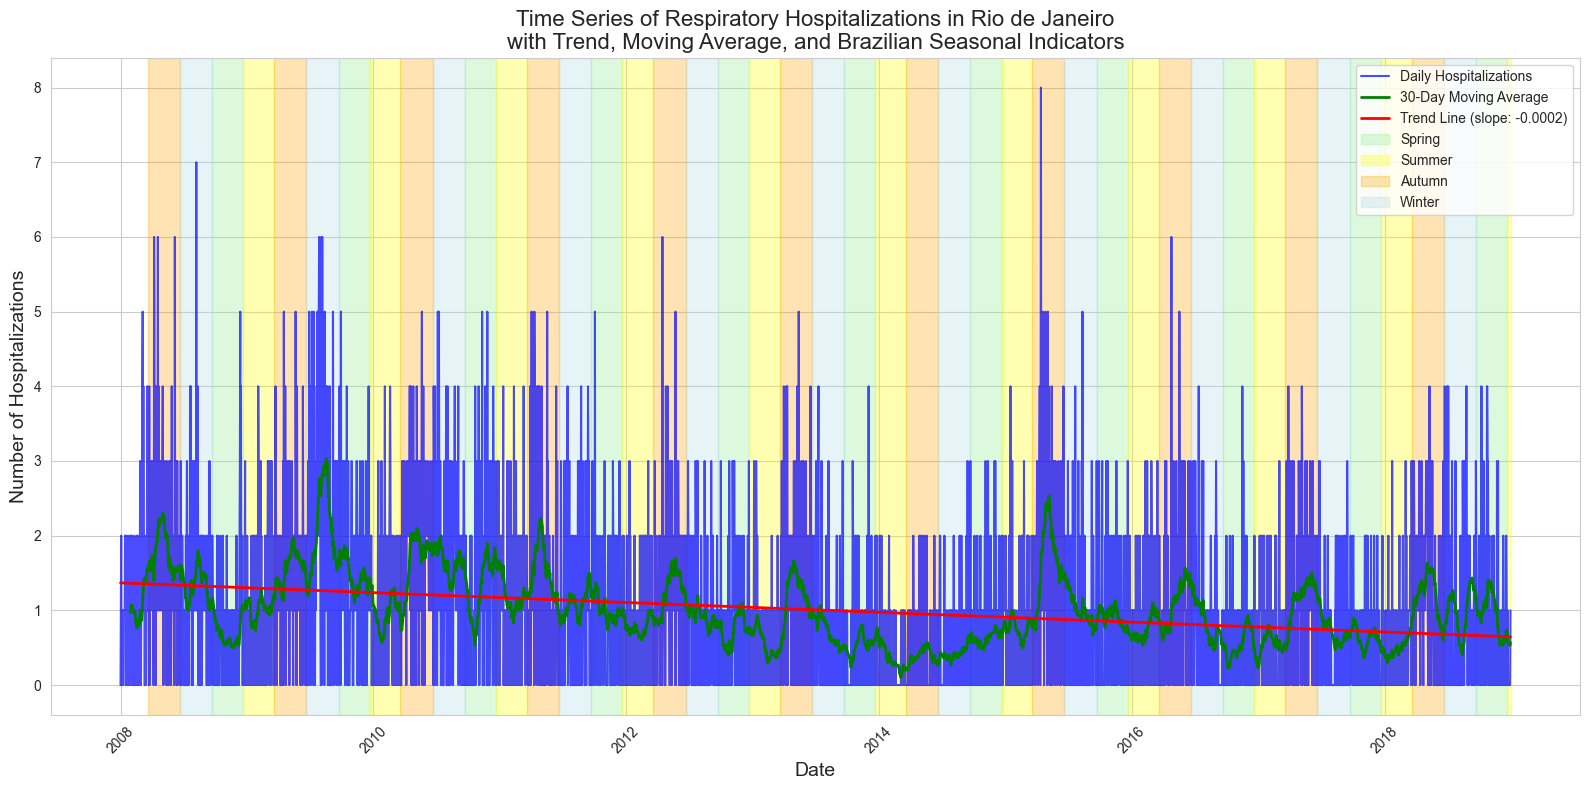

In [30]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Série temporal de hospitalizações diárias
plt.plot(internacoes_diario_hospital_grafico['data_dia'], internacoes_diario_hospital_grafico['num_internacoes'], linewidth=1.5, color='blue', alpha=0.7, label='Daily Hospitalizations')

# Média móvel de 30 dias
internacoes_diario_hospital_grafico['moving_avg_30'] = internacoes_diario_hospital_grafico['num_internacoes'].rolling(window=30).mean()
plt.plot(internacoes_diario_hospital_grafico['data_dia'], internacoes_diario_hospital_grafico['moving_avg_30'], linewidth=2, color='green', label='30-Day Moving Average')

# Calcula a tendência linear (slope) e plota a linha de tendência
x_numeric = (internacoes_diario_hospital_grafico['data_dia'] - internacoes_diario_hospital_grafico['data_dia'].min()).dt.days
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, internacoes_diario_hospital_grafico['num_internacoes'])
trend_line = slope * x_numeric + intercept
plt.plot(internacoes_diario_hospital_grafico['data_dia'], trend_line, color='red', linewidth=2, label=f'Trend Line (slope: {slope:.4f})')

# Adicionar indicadores sazonais brasileiros (estações do ano)
start_date = internacoes_diario_hospital_grafico['data_dia'].min()
end_date = internacoes_diario_hospital_grafico['data_dia'].max()

# Datas das estações do ano
def get_season_periods(year):
    return [
        ('Spring', pd.Timestamp(year=year, month=9, day=22), pd.Timestamp(year=year, month=12, day=21)),
        ('Summer', pd.Timestamp(year=year, month=12, day=21), pd.Timestamp(year=year+1, month=3, day=20)),
        ('Autumn', pd.Timestamp(year=year, month=3, day=20), pd.Timestamp(year=year, month=6, day=21)),
        ('Winter', pd.Timestamp(year=year, month=6, day=21), pd.Timestamp(year=year, month=9, day=22))
    ]

season_colors = {
    'Spring': ('lightgreen', 0.3),
    'Summer': ('yellow', 0.3),
    'Autumn': ('orange', 0.3),
    'Winter': ('lightblue', 0.3)
}

for year in range(start_date.year, end_date.year + 1):
    season_periods = get_season_periods(year)
    for season_name, season_start, season_end in season_periods:
        # Adjust for data range
        actual_start = max(season_start, start_date)
        actual_end = min(season_end, end_date)
        if actual_start < actual_end:
            color, alpha = season_colors[season_name]
            plt.axvspan(actual_start, actual_end, color=color, alpha=alpha, label=season_name if year == start_date.year else "")

plt.title('Time Series of Respiratory Hospitalizations in Rio de Janeiro\nwith Trend, Moving Average, and Brazilian Seasonal Indicators', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Hospitalizations', fontsize=14)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()